**Overview**  
This notebook describes folloiwing stages:
1. Creating functions to:
    - perform search for optimal algorithm parameters;
    - train model;
    - calculate the most important metrics;
    - plot ROC-AUC curve
2. Assess the results of following algorithms:
    - Logistic regression;
    - Random Forest;
    - Gradient Boosting as implemented in XGBoost;
    - Support Vector Machines;
    - K-Nearest Neighborrs
3. Creare dataframe with the main indiators of models' performance


In [24]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from hyperopt import tpe, Trials, hp, fmin, STATUS_OK
from functools import partial
from sklearn.neighbors import KNeighborsRegressor

First, let's import datasets and y-target, created earlier:

In [25]:
with open ('padel_descks.pickle', 'rb') as inp:
    padel_descs = pickle.load(inp)

In [26]:
data_ionic = pd.read_csv('Data_ionic.csv')
target_ionic = data_ionic['Cc ']

data_extended = pd.read_csv('Data_extended.csv')
target_extended = data_extended['Cc ']

data_non_ionic = pd.read_csv('Data_non_ionic.csv')
target_non_ionic = data_non_ionic['Cc ']

targets = {'Padel_ionic': target_ionic, 'Padel_non_ionic': target_non_ionic, 'Padel_extended':target_extended}

In [27]:
scores_ionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_non_ionic = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores_extended = {'Descriptors':[], 'Estimator': [], 'R2_cv':[], 'MAE_cv':[], 'RMSE_cv':[],
          'R2_test':[], 'RMSE_test':[], 'MAE_test':[], 'R2_train':[], 'RMSE_train':[], 'MAE_train':[] }

scores = {'Padel_ionic': scores_ionic, 'Padel_non_ionic': scores_non_ionic, 'Padel_extended':scores_extended}

In [28]:
def get_best_model_from_trials(trials):
    valid_trial_list = [trial for trial in trials if trial['result']['status'] == STATUS_OK]
    losses = [ float(trial['result']['loss']) for trial in valid_trial_list]
    index_having_minumum_loss = np.argmin(losses)
    best_trial_obj = valid_trial_list[index_having_minumum_loss]
    return best_trial_obj['result']

In [29]:
def calculate_to_score(estimator, estimator_name, param_grid, descriptors_dict = padel_descs, targets = targets, n_iters = 150):
    fig, axes = plt.subplots(1, 3, figsize = (12,8))
    i = 0
    
    for key, value in descriptors_dict.items():
        target = targets[key]
        X_train, X_test, y_train, y_test = train_test_split(value, target, random_state = 0)
        def objective(params, X, target):
            pipe = make_pipeline(StandardScaler(), estimator)
            pipe.set_params(**params)
            y_cv_pred = cross_val_predict(pipe, X, target, cv=5)
            cv_rmse = np.sqrt(root_mean_squared_error(target, y_cv_pred))
            cv_r2 = r2_score(target, y_cv_pred)
            
            score = cross_val_score(pipe, X, target, cv = 10, scoring = 'neg_mean_absolute_error')
            return {'loss':-score.mean(), 'status':STATUS_OK, 'Trained_model':pipe, 'rmse':cv_rmse, 'r2':cv_r2}
        
        trials = Trials()
        best = fmin(partial(objective, X = X_train, target = y_train), space = param_grid, trials = trials, algo = tpe.suggest, max_evals=  n_iters)
        print(best)
        
        best_estimator  = get_best_model_from_trials(trials)['Trained_model']
      
        
        cv_r2 = get_best_model_from_trials(trials)['r2']
        cv_rmse = get_best_model_from_trials(trials)['rmse']
        cv_mae = get_best_model_from_trials(trials)['loss']
        
        scores[key]['Descriptors'].append('Padel')
        scores[key]['R2_cv'].append(cv_r2)
        scores[key]['RMSE_cv'].append(cv_rmse)
        scores[key]['MAE_cv'].append(cv_mae)
        
        best_estimator.fit(X_train, y_train)
        predictions = best_estimator.predict(X_test)
        predictions_train = best_estimator.predict(X_train)
        scores[key]['Estimator'].append(estimator_name)
        scores[key]['R2_test'].append(r2_score(y_test, predictions))
        scores[key]['R2_train'].append(r2_score(y_train, predictions_train))
        
        scores[key]['RMSE_test'].append(root_mean_squared_error(y_test, predictions))
        scores[key]['RMSE_train'].append(root_mean_squared_error(y_train, predictions_train))

        
        scores[key]['MAE_test'].append(mean_absolute_error(y_test, predictions))
        scores[key]['MAE_train'].append(mean_absolute_error(y_train, predictions_train))
        
        axes[i].plot(y_test, predictions, 'ro', label = 'Test values')
        axes[i].plot(y_train, predictions_train, 'go', label = 'Train values')
        axes[i].plot([target.min(),target.max()], [target.min(),target.max()])
        axes[i].set_title('{}'.format(key))
        axes[i].set_xlabel('True test values')
        axes[i].set_ylabel('Predicted test values')
        axes[i].legend()
        i += 1
    plt.tight_layout()
    plt.savefig('All_classes_Padel_{}_scattter.png'.format(estimator_name))

Subfunction below is to retrieve best model from Trials object ans is used in main functions

Let's initialize scores dictionary and test function with Logistic Regression

100%|███████████████████████████████████████████████| 150/150 [08:26<00:00,  3.38s/trial, best loss: 1.638033509760446]
{'alpha': 0.365712894785727, 'solver': 6}
100%|███████████████████████████████████████████████| 150/150 [06:45<00:00,  2.70s/trial, best loss: 8.462787389570442]
{'alpha': 99.95870013298763, 'solver': 2}
100%|██████████████████████████████████████████████| 150/150 [00:59<00:00,  2.52trial/s, best loss: 0.7723736135457625]
{'alpha': 12.975274739355912, 'solver': 3}


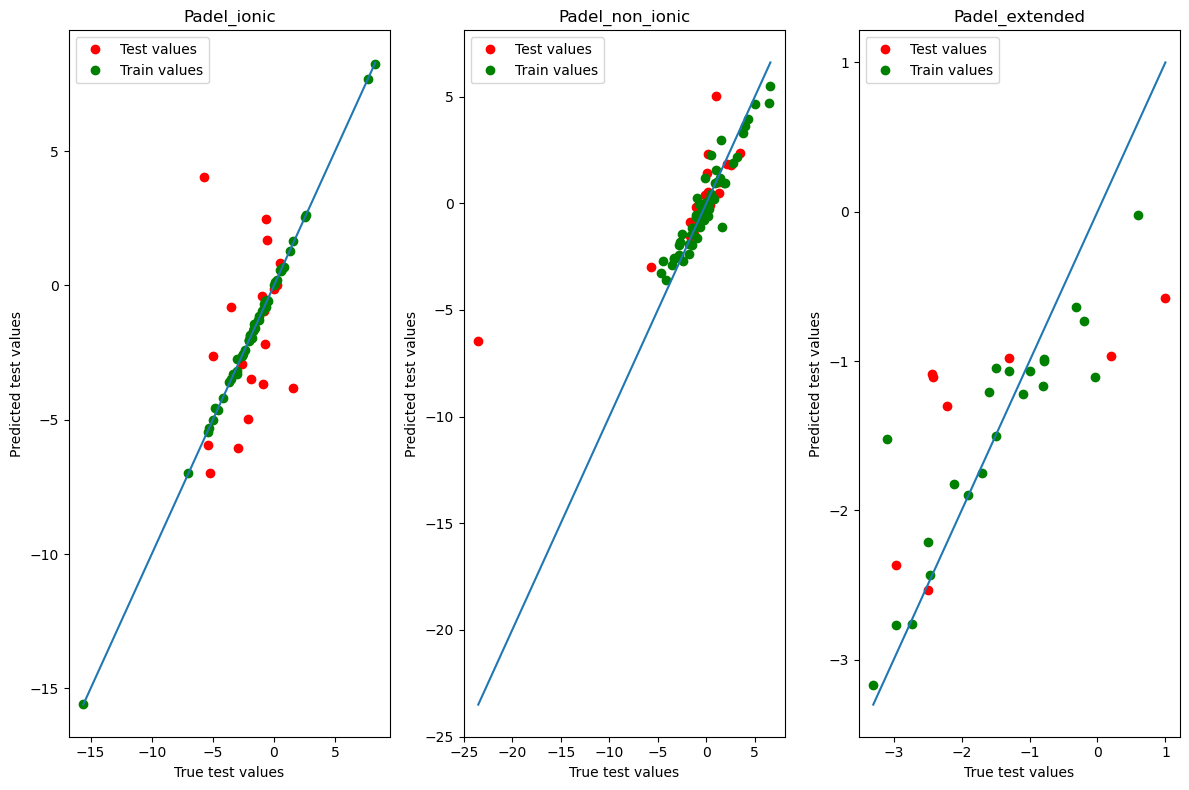

In [30]:
calculate_to_score(Ridge(max_iter = 10000), estimator_name='Linear Regression', 
                   param_grid = {'ridge__alpha':hp.loguniform(label = 'alpha', low = -4*np.log(10), high  = 2*np.log(10)),
                                'ridge__solver':hp.choice(label = 'solver', options = ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg','sag', 'saga'])})

Let's continue with other models. The first one will be
**Random Forest Classification**

In [31]:
space = {
    'randomforestregressor__max_depth': hp.randint('max_depth', 3, 15),  
    'randomforestregressor__max_features': hp.choice('max_features', [0.3, 0.5, 'sqrt', 'log2']), 
    'randomforestregressor__min_samples_split': hp.randint('min_samples_split', 5, 20),  
    'randomforestregressor__min_samples_leaf': hp.randint('min_samples_leaf', 3, 10), 
    'randomforestregressor__criterion': hp.choice('criterion', ["squared_error", "absolute_error"]), 
    'randomforestregressor__ccp_alpha': hp.uniform('ccp_alpha', 0, 0.1),  
    'randomforestregressor__n_estimators': hp.randint('n_estimators', 50, 200),  
    'randomforestregressor__bootstrap': hp.choice('bootstrap', [True]),  
    'randomforestregressor__max_samples': hp.uniform('max_samples', 0.6, 0.95)} 

100%|██████████████████████████████████████████████| 150/150 [06:27<00:00,  2.58s/trial, best loss: 1.6649393074753944]
{'bootstrap': 0, 'ccp_alpha': 0.049925032891580845, 'criterion': 0, 'max_depth': 8, 'max_features': 0, 'max_samples': 0.712681572222365, 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 114}
100%|████████████████████████████████████████████████| 150/150 [06:56<00:00,  2.78s/trial, best loss: 1.24717519324223]
{'bootstrap': 0, 'ccp_alpha': 0.051216094949216195, 'criterion': 0, 'max_depth': 6, 'max_features': 2, 'max_samples': 0.8053558087309444, 'min_samples_leaf': 5, 'min_samples_split': 6, 'n_estimators': 164}
100%|███████████████████████████████████████████████| 150/150 [06:33<00:00,  2.62s/trial, best loss: 0.798433062102281]
{'bootstrap': 0, 'ccp_alpha': 0.09503043281384306, 'criterion': 0, 'max_depth': 12, 'max_features': 0, 'max_samples': 0.7401844864208883, 'min_samples_leaf': 5, 'min_samples_split': 6, 'n_estimators': 148}


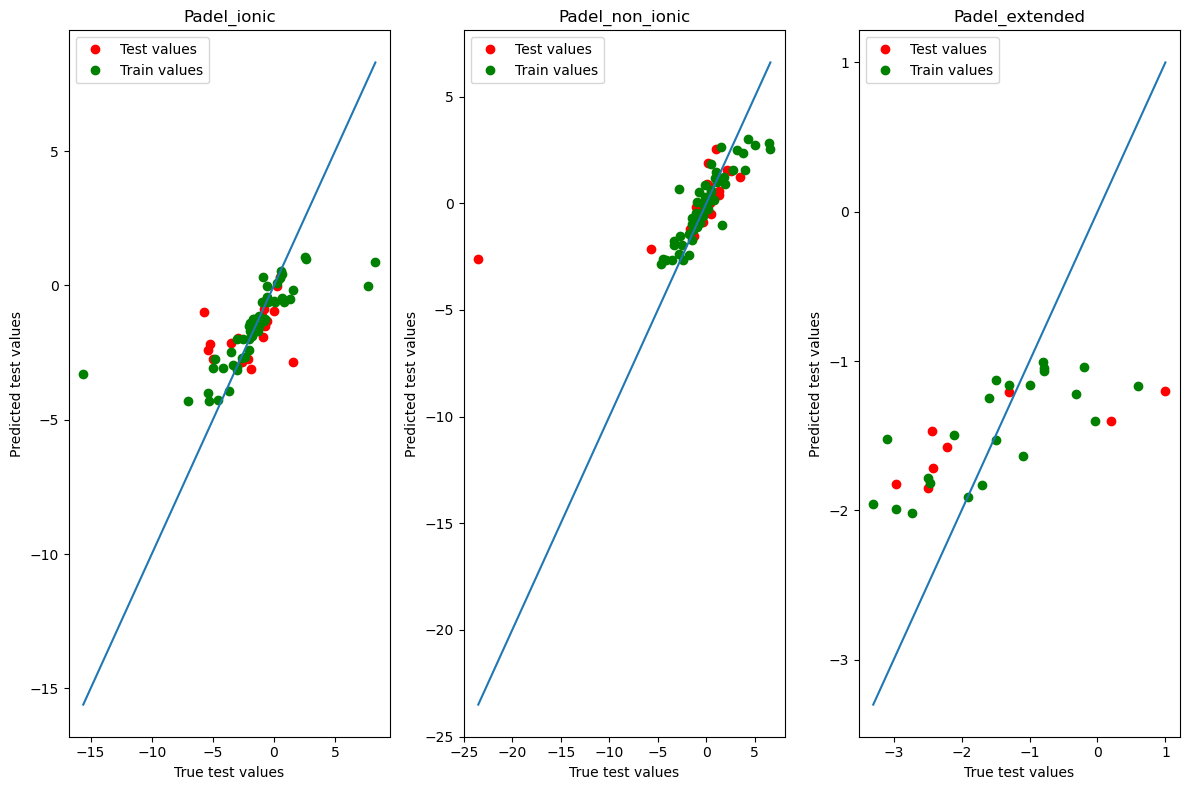

In [32]:
calculate_to_score(RandomForestRegressor(random_state = 0, n_jobs=-1), estimator_name = 'Random Forest', param_grid =  space)
               

**LightGBM**

In [33]:
space = {'lgbmregressor__max_depth':hp.randint('max_depth', 3, 12),
        'lgbmregressor__boosting_type':hp.choice('boosting_type', ['gbdt']),
        'lgbmregressor__reg_alpha':hp.loguniform('reg_alpha', -3*np.log(10), 1*np.log(10)),
         'lgbmregressor__reg_lamdba':hp.loguniform('reg_lambda', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__learning_rate':hp.loguniform('learning_rate', -3*np.log(10), 1*np.log(10)),
        'lgbmregressor__n_estimators':hp.randint('n_estimators', 50, 300),
        'lgbmregressor__n_leaves':hp.randint('n_leaves', 10, 50),
        'lgbmregressor__min_child_samples': hp.randint('min_child_samples', 5, 30)}

100%|██████████████████████████████████████████████| 150/150 [01:49<00:00,  1.37trial/s, best loss: 1.5913145632198336]
{'boosting_type': 0, 'learning_rate': 0.016827419898214062, 'max_depth': 6, 'min_child_samples': 8, 'n_estimators': 178, 'n_leaves': 17, 'reg_alpha': 0.10887992687759092, 'reg_lambda': 0.03606457406755906}
100%|███████████████████████████████████████████████| 150/150 [01:34<00:00,  1.59trial/s, best loss: 1.059299574537166]
{'boosting_type': 0, 'learning_rate': 0.45872509641511733, 'max_depth': 10, 'min_child_samples': 16, 'n_estimators': 243, 'n_leaves': 16, 'reg_alpha': 0.11737779155361291, 'reg_lambda': 0.064025069082227}
100%|██████████████████████████████████████████████| 150/150 [00:58<00:00,  2.57trial/s, best loss: 0.8117805246245633]
{'boosting_type': 0, 'learning_rate': 0.008474207114007266, 'max_depth': 3, 'min_child_samples': 9, 'n_estimators': 236, 'n_leaves': 10, 'reg_alpha': 0.1234427948485872, 'reg_lambda': 0.6312927630132865}


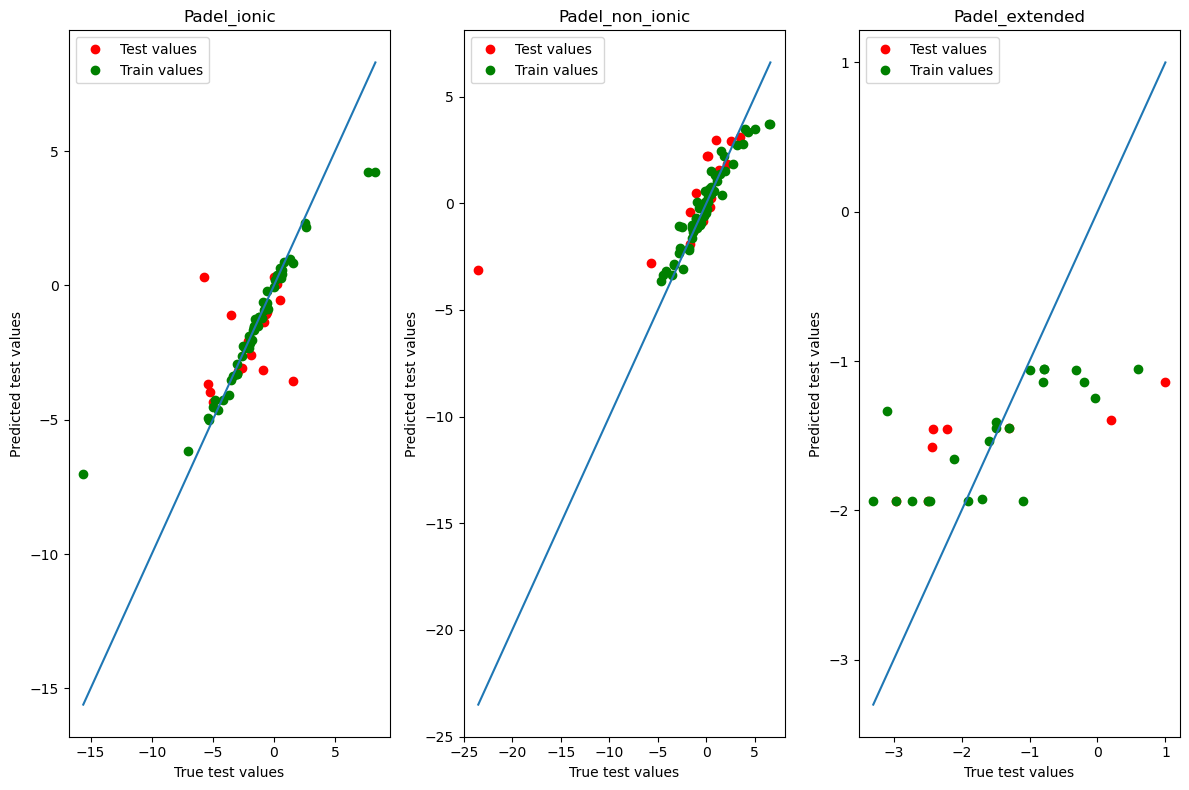

In [34]:
calculate_to_score(LGBMRegressor(verbosity = -1), estimator_name='Gradient boosting', param_grid = space)

**SVM**

In [35]:
space = {'svr__C':hp.loguniform('C', -2*np.log(10), 1*np.log(10)),
         'svr__kernel':hp.choice('kernel', ['rbf','poly','linear', 'sigmoid']),
         'svr__degree':hp.choice('degree', [2,3,4]),
         'svr__gamma':hp.choice('gamma', ['scale', 'auto']),
         'svr__coef0':hp.loguniform('coef0', -1, 1)}


100%|██████████████████████████████████████████████| 500/500 [01:57<00:00,  4.25trial/s, best loss: 1.4075086658987628]
{'C': 5.0143006310145966, 'coef0': 1.9947757913187996, 'degree': 2, 'gamma': 0, 'kernel': 1}
  9%|████▎                                          | 46/500 [00:11<02:00,  3.76trial/s, best loss: 1.1927486960581057]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



 15%|███████▏                                       | 77/500 [00:18<01:45,  4.00trial/s, best loss: 1.1927486960581057]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



 17%|███████▉                                       | 84/500 [00:20<01:47,  3.89trial/s, best loss: 1.1927486960581057]

...

 97%|█████████████████████████████████████████████▊ | 487/500 [01:58<00:03,  3.75trial/s, best loss: 1.192296563175053]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



 99%|██████████████████████████████████████████████▋| 497/500 [02:01<00:00,  3.74trial/s, best loss: 1.192296563175053]

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(

C:\Users\Timur\anaconda3\envs\ChemInfo-Pytorch\Lib\site-packages\sklearn\svm\_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=15000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(



100%|███████████████████████████████████████████████| 500/500 [02:02<00:00,  4.09trial/s, best loss: 1.192296563175053]
{'C': 9.99268454469709, 'coef0': 1.7733866547506185, 'degree': 0, 'gamma': 1, 'kernel': 0}
100%|██████████████████████████████████████████████| 500/500 [01:53<00:00,  4.42trial/s, best loss: 0.5064335020589421]
{'C': 6.4975801821899095, 'coef0': 0.4220799418074153, 'degree': 0, 'gamma': 0, 'kernel': 3}


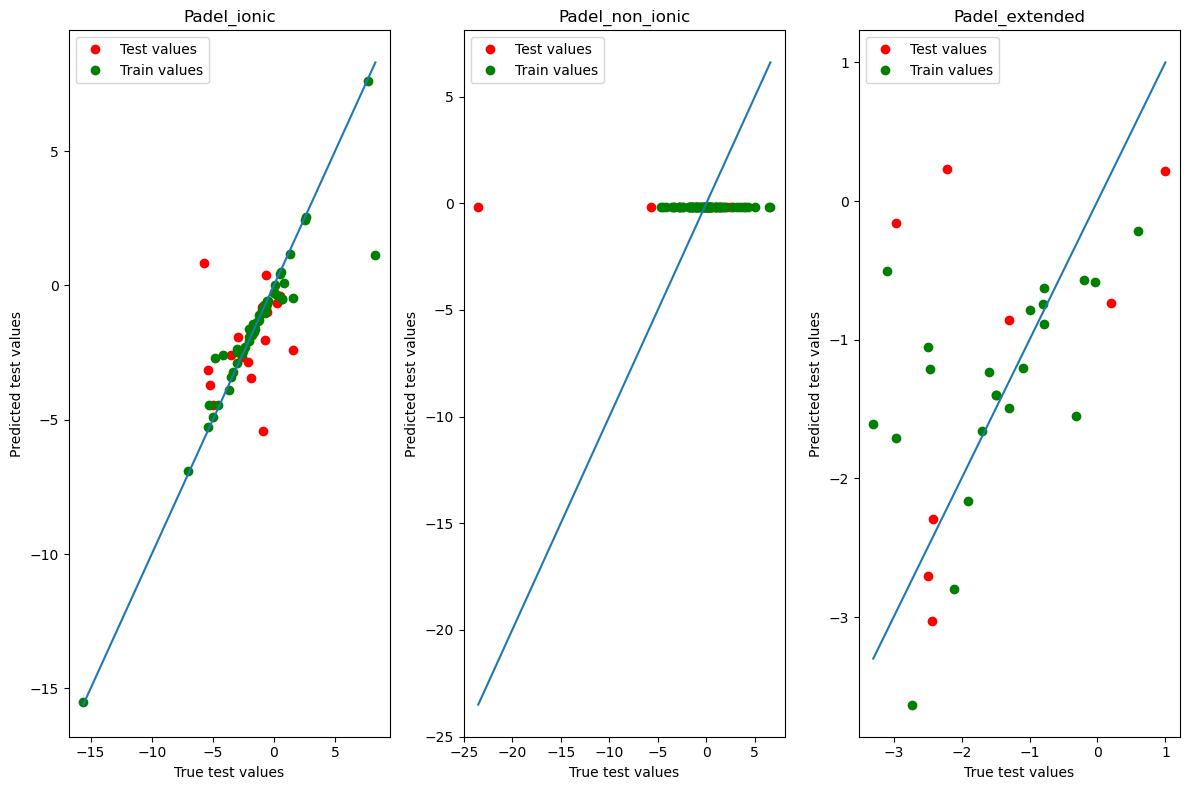

In [36]:
calculate_to_score(SVR(max_iter = 15000), estimator_name = 'SVR', param_grid = space, n_iters = 500)
                                                                


**KNearestneighbors**

In [37]:
space = {
    'kneighborsregressor__n_neighbors': hp.randint('n_neighbors', 3, 16),  # Увеличил диапазон
    'kneighborsregressor__weights': hp.choice('weights', ['uniform', 'distance']),
    'kneighborsregressor__metric': hp.choice('metric', ['minkowski', 'euclidean', 'manhattan']),  # Упростил выбор
    'kneighborsregressor__p': hp.uniform('p', 1, 3),  # Параметр для minkowski
    'kneighborsregressor__algorithm': hp.choice('algorithm', ['auto', 'ball_tree', 'kd_tree']),
    'kneighborsregressor__leaf_size': hp.randint('leaf_size', 10, 50)  # Для tree-based алгоритмов
}

100%|██████████████████████████████████████████████| 150/150 [00:33<00:00,  4.46trial/s, best loss: 1.5854108714850854]
{'algorithm': 0, 'leaf_size': 10, 'metric': 2, 'n_neighbors': 4, 'p': 1.854393748192865, 'weights': 1}
100%|██████████████████████████████████████████████| 150/150 [00:34<00:00,  4.29trial/s, best loss: 1.3933916263054296]
{'algorithm': 0, 'leaf_size': 18, 'metric': 2, 'n_neighbors': 8, 'p': 1.1556056868909625, 'weights': 1}
100%|███████████████████████████████████████████████| 150/150 [00:33<00:00,  4.46trial/s, best loss: 0.748944044265091]
{'algorithm': 1, 'leaf_size': 23, 'metric': 2, 'n_neighbors': 3, 'p': 1.769079900025841, 'weights': 1}


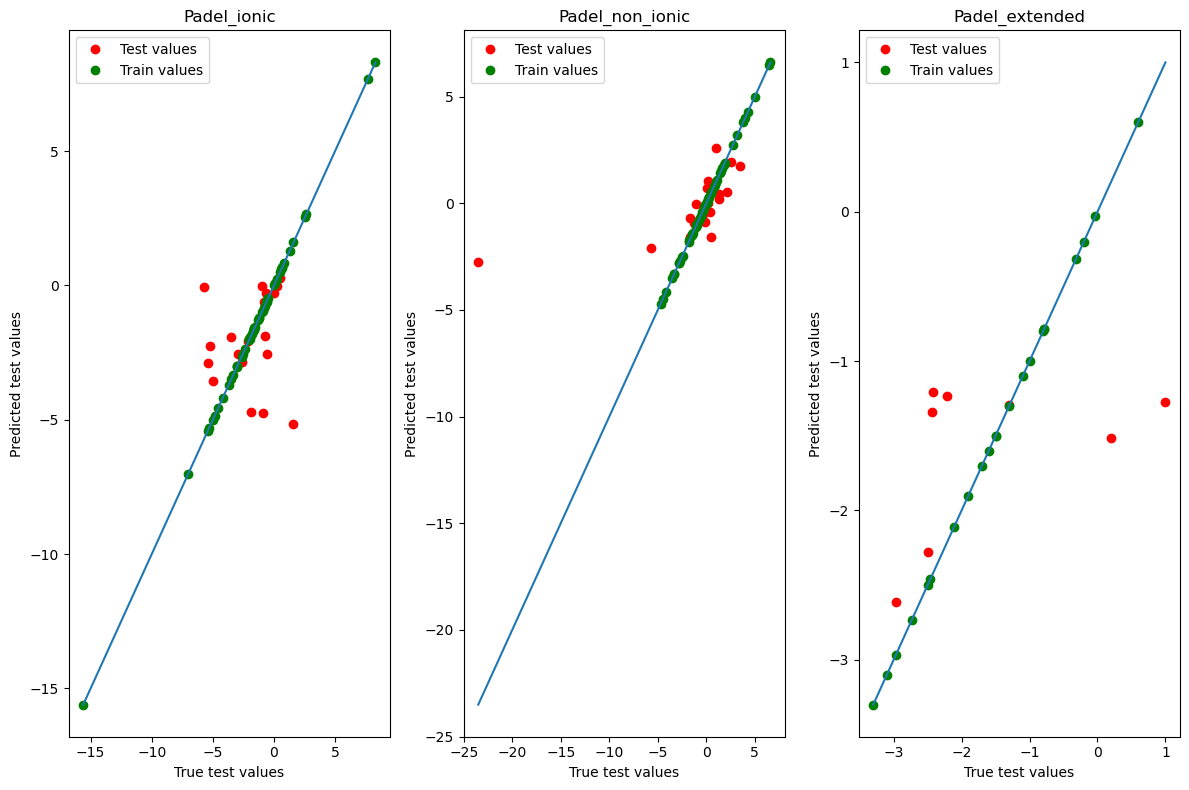

In [38]:
calculate_to_score(KNeighborsRegressor(), estimator_name='KMeans', param_grid=space)

Let's save results into pickle file and show the final scores model in readable format

In [18]:
with open('scores_padel_descs.pickle', 'wb') as output:
    pickle.dump(scores, output)

In [19]:
with open('scores_padel_descs.pickle', 'rb') as inp:
    scores = pickle.load(inp)

In [39]:
pd.DataFrame(scores_ionic)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,Padel,Linear Regression,-0.836613,1.638034,2.117213,-1.193315,3.130274,2.182936,0.999098,0.099352,0.064699
1,Padel,Random Forest,-0.039095,1.664939,1.836217,0.135391,1.965358,1.394243,0.478546,2.388516,1.117308
2,Padel,Gradient boosting,-0.051477,1.591315,1.841662,0.045459,2.065042,1.265755,0.819880,1.403787,0.499138
3,Padel,SVR,-0.438807,1.407509,1.991869,-0.135686,2.252480,1.510568,0.883609,1.128445,0.445050
4,Padel,KMeans,-0.085755,1.585411,1.856492,-0.489389,2.579502,1.763608,1.000000,0.000000,0.000000


In [40]:
pd.DataFrame(scores_non_ionic)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,Padel,Linear Regression,-412.677365,8.462787,7.080107,0.454372,4.134470,1.814236,0.886756,0.829387,0.633107
1,Padel,Random Forest,0.410281,1.247175,1.375738,0.217228,4.952098,2.039868,0.729520,1.281789,0.880199
2,Padel,Gradient boosting,0.521097,1.059300,1.305979,0.258275,4.820509,1.888315,0.886076,0.831870,0.591128
3,Padel,SVR,0.537404,1.192297,1.294717,-0.030857,5.682909,2.583815,0.001246,2.463077,1.834367
4,Padel,KMeans,0.394629,1.393392,1.384777,0.224170,4.930091,2.086340,1.000000,0.000000,0.000000


In [41]:
pd.DataFrame(scores_extended)

,Descriptors,Estimator,R2_cv,MAE_cv,RMSE_cv,R2_test,RMSE_test,MAE_test,R2_train,RMSE_train,MAE_train
0,Padel,Linear Regression,0.307229,0.772374,0.928630,0.401539,1.042344,0.909910,0.775435,0.490978,0.327467
1,Padel,Random Forest,0.035964,0.798433,1.008599,0.243051,1.172267,1.000521,0.390164,0.809091,0.634367
2,Padel,Gradient boosting,-0.069030,0.811781,1.035006,0.257701,1.160867,1.008945,0.399487,0.802883,0.611207
3,Padel,SVR,-0.122272,0.506434,1.047659,-0.102808,1.414956,1.044294,0.189811,0.932575,0.659777
4,Padel,KMeans,0.092832,0.748944,0.993385,0.178933,1.220906,0.982531,1.000000,0.000000,0.000000
